# Exploratory Data Analysis (EDA)

This notebook focuses on exploring and understanding the visual characteristics of the rice leaf disease dataset. The analysis aims to identify visible differences between healthy and diseased rice leaves, investigate patterns across disease categories, and evaluate dataset balance and image quality.

The notebook supports the business requirement of visually differentiating rice leaf diseases and helps validate the project hypotheses before model development.

The analysis includes image sampling, class distribution analysis, color and pattern exploration, and visual comparisons between disease categories.


## Objectives

- Explore the visual characteristics of rice leaf images.
- Compare healthy and diseased rice leaves.
- Identify visual patterns associated with different disease categories.
- Investigate class imbalance and image distribution.
- Validate assumptions and hypotheses through visual analysis.
- Generate plots and outputs for later use in the dashboard.


## Inputs

- Raw rice leaf disease dataset  
  (`inputs/datasets/raw/`)
  
- Dataset metadata generated during data collection  
  (`outputs/datasets/collection/class_distribution.csv`)


## Outputs

- Sample image visualizations
- Class distribution plots
- Disease comparison figures
- Image dimension and quality analysis
- Saved visual outputs for dashboard usage:
  - `outputs/datasets/eda/`


## Additional Comments

- The dataset was originally structured for object detection tasks in YOLO format but will be used in this project for image classification.
- The dataset contains class imbalance, which may influence later model performance.
- Exploratory analysis results from this notebook will support hypothesis validation and guide preprocessing decisions.


## Steps to Implement the Notebook

### 1. Load Python Packages and Project Dependencies

This section imports the Python libraries and dependencies required for data manipulation, image processing, visualisation, and file handling throughout the notebook.

In [8]:
# Data handling
import pandas as pd
import numpy as np

# File and path handling
from pathlib import Path
import os
import random

# Image processing
from PIL import Image

# Data visualisation
import matplotlib.pyplot as plt

# Utility collections
from collections import Counter, defaultdict

### 2. Set Working Directory

This section configures the notebook working directory to the project root and defines reusable paths used throughout the analysis.

In [2]:
def setup_root():
    current_path = Path().resolve()
    # Search upwards for project root
    while not (current_path / "requirements.txt").exists():
        if current_path == current_path.parent:
            raise FileNotFoundError(
                "Project root not found. Ensure requirements.txt exists."
            )
        current_path = current_path.parent
    return current_path


# Set project root
PROJECT_ROOT = setup_root()

# Change working directory
os.chdir(PROJECT_ROOT)
print(f"New working directory: {PROJECT_ROOT}")


# Define dataset and output paths
DATASET_DIR = Path("inputs/datasets/raw/rice")

OUTPUT_DIR = Path("outputs/datasets/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset directory: {DATASET_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

New working directory: C:\code\ml\workspace\rice_leaf_diseases_analyser
Dataset directory: inputs\datasets\raw\rice
Output directory: outputs\datasets\eda


### 3. Load Dataset Metadata

Load metadata and outputs generated during the Data Collection notebook for use in exploratory analysis.

In [3]:
# Load class distribution data
class_distribution_path = (
    Path("outputs/datasets/collection/class_distribution.csv")
)

df_class_distribution = pd.read_csv(class_distribution_path)

print("Class distribution data loaded successfully.")
df_class_distribution.head()

Class distribution data loaded successfully.


,Class,Count
0,BrownSpot,12368
1,LeafSmut,5174
2,BacterialLeafBlight,1876
3,NeckBlast,771
4,Hispa,734


### 4. Inspect Dataset Structure

Inspect the dataset structure, verify class availability, and confirm that image files are accessible for exploratory analysis.

In [6]:
# Define image directories
train_images_dir = DATASET_DIR / "images" / "train"
val_images_dir = DATASET_DIR / "images" / "val"

# Supported image extensions
image_extensions = [".jpg", ".jpeg", ".png"]

# Collect image files
train_images = [
    file for file in train_images_dir.glob("*")
    if file.suffix.lower() in image_extensions
]

val_images = [
    file for file in val_images_dir.glob("*")
    if file.suffix.lower() in image_extensions
]

print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")

Training images: 6935
Validation images: 1730


### 5. Display Sample Images

Visualize random rice leaf images to explore visual characteristics, disease patterns, and differences between healthy and diseased leaves.

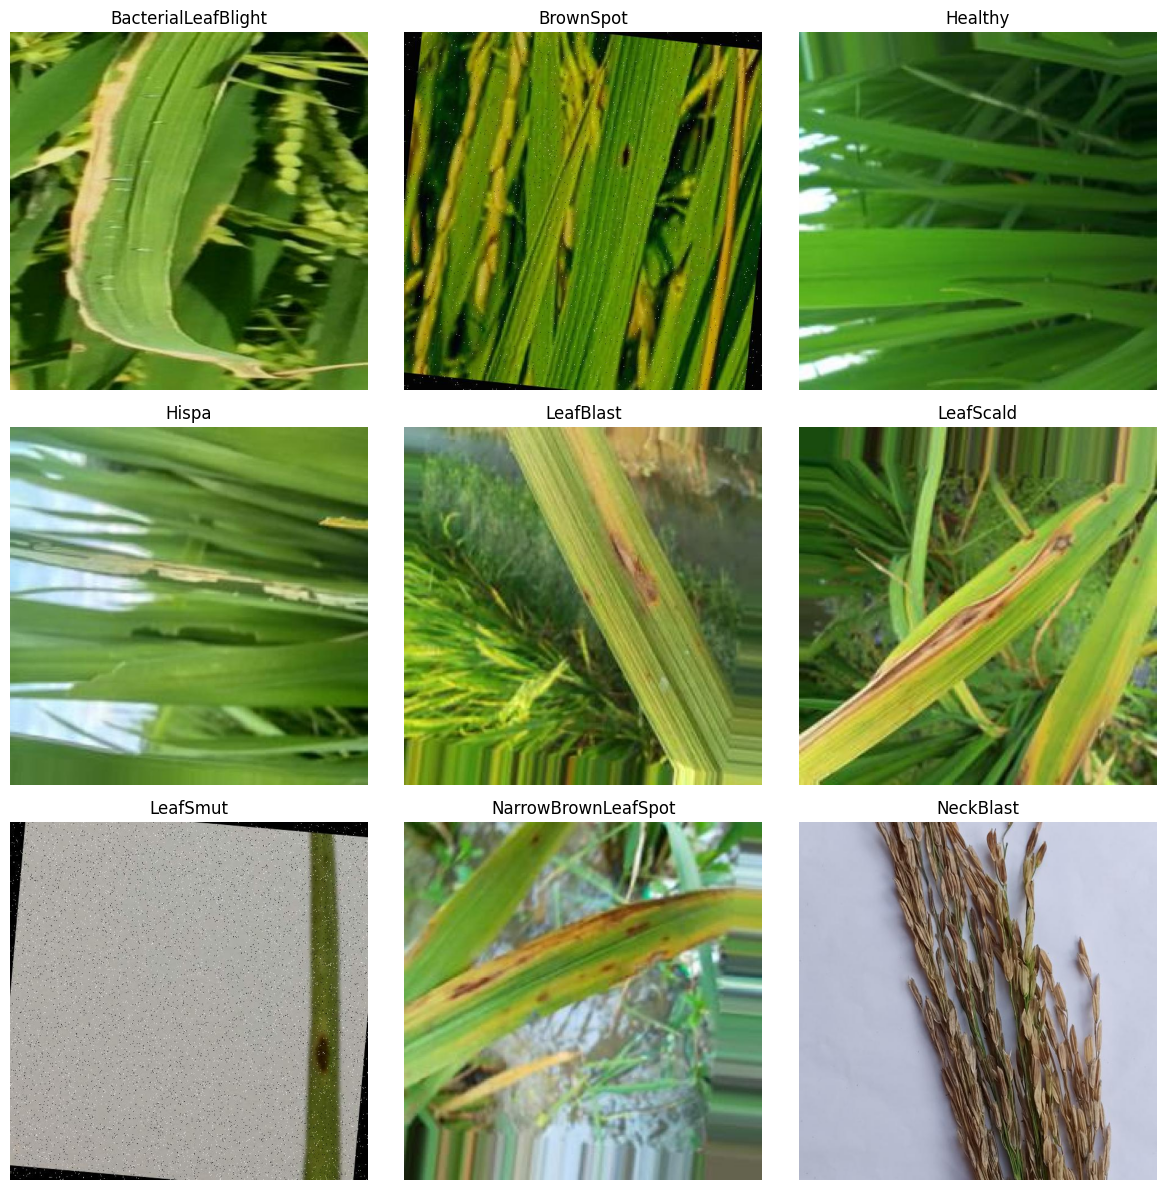

In [11]:
# Class Mapping
class_names = {
    0: "BacterialLeafBlight",
    1: "BrownSpot",
    2: "Healthy",
    3: "Hispa",
    4: "LeafBlast",
    5: "LeafScald",
    6: "LeafSmut",
    7: "NarrowBrownLeafSpot",
    8: "NeckBlast"
}

# Create mapping between class IDs and image paths
class_image_map = defaultdict(list)

labels_dir = DATASET_DIR / "labels" / "train"

for label_file in labels_dir.glob("*.txt"):

    with open(label_file, "r") as f:
        lines = f.readlines()

    if not lines:
        continue

    # Take first class in annotation file
    class_id = int(lines[0].split()[0])

    for ext in [".jpg", ".jpeg", ".png"]:
        image_path = train_images_dir / f"{label_file.stem}{ext}"

        if image_path.exists():
            class_image_map[class_id].append(image_path)
            break

# Display random samples
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx, (class_id, class_name) in enumerate(class_names.items()):

    if class_image_map[class_id]:

        image_path = random.choice(class_image_map[class_id])

        img = Image.open(image_path)

        ax = axes[idx // 3, idx % 3]
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")

plt.tight_layout()
plt.show()